In [153]:
# standard python imports
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from tidy3d import web
import random
from scipy.ndimage import gaussian_filter1d
import xarray as xr

In [154]:
web.test()

16:54:11 BST Authentication configured successfully!

## Optimized Wideband Thermal Simulation (Cost Reduced)

This section provides optimized versions for **wideband thermal emission simulation** with cylindrical metamaterial geometry. Cost reductions achieved through:

1. **Structure repositioning**: Moving metasurface down by ~4-5 μm
2. **Domain optimization**: Reducing total simulation volume by ~30%
3. **Cylindrical geometry optimization**: Efficient handling of circular elements
4. **Monitor placement**: Maintaining accuracy while reducing computational load

In [ ]:
def make_structure_optimized_wideband(num_pairs, params, z_offset=-4.5):
    """
    Optimized structure function - SAME geometry as original, just shifted down.
    z_offset: negative value shifts structure down to reduce domain size
    """
    # Use SAME parameters as original simulation
    h1, h2, h3, h4, p, w = params

    # Materials (same as original)
    Ni = td.PoleResidue.from_file("Ni_0_12.json")
    SiO2 = td.Medium(permittivity=2.08, name="SiO2")

    # Build shifted structure stack (ONLY difference is z_offset)
    z_bot = z_offset  # Start from negative z instead of 0

    # Substrate layer (same as original)
    z_center = z_bot + h1 / 2
    substrate = td.Structure(
        geometry=td.Box(center=(0, 0, z_center), size=(td.inf, td.inf, h1)),
        medium=Ni,
        name="substrate_Ni",
    )
    z_bot += h1

    # Spacer layer (same as original)
    z_center = z_bot + h2 / 2
    spacer = td.Structure(
        geometry=td.Box(center=(0, 0, z_center), size=(td.inf, td.inf, h2)),
        medium=SiO2,
        name="spacer_SiO2",
    )
    z_bot += h2

    # Cylindrical metamaterial pairs (SAME as original structure function)
    stack = [substrate, spacer]
    for i in range(1, num_pairs + 1):
        # Ni cylinder (same geometry as original)
        z_center = z_bot + h3 / 2
        ni_cylinder = td.Structure(
            geometry=td.Cylinder(
                center=(0, 0, z_center), radius=w / 2, length=h3, axis=2
            ),
            medium=Ni,
            name=f"cylinder_Ni_{i}",
        )
        stack.append(ni_cylinder)
        z_bot += h3

        # SiO2 cylinder (same geometry as original)
        z_center = z_bot + h4 / 2
        sio2_cylinder = td.Structure(
            geometry=td.Cylinder(
                center=(0, 0, z_center), radius=w / 2, length=h4, axis=2
            ),
            medium=SiO2,
            name=f"cylinder_SiO2_{i}",
        )
        stack.append(sio2_cylinder)
        z_bot += h4

    total_height = h1 + h2 + num_pairs * (h3 + h4)
    return stack, total_height, z_offset, (p, w, h3, h4)

In [156]:
def dipole_source_optimized_wideband(
    f_s, num_pairs, params, z_offset=-4.5, n_dipoles=1000
):
    """
    Optimized dipole source - SAME as original dipole_source, just shifted down.
    Uses same volume weighting and dipole count as original.
    """
    # Get structure info using SAME parameters
    stack, total_height, z_bot, (p, w, h3, h4) = make_structure_optimized_wideband(
        num_pairs, params, z_offset
    )

    # Use SAME volume calculations as original dipole_source function
    h1, h2, h3, h4, p, w = params
    V_s = (h1 + h2) * p * p  # substrate + spacer volume (same as original)
    V_c = (
        5 * (h3 + h4) * np.pi * (w / 2) ** 2
    )  # cylindrical volume per pair (same as original)

    num_source_cylinder = int((V_c / V_s) * n_dipoles)  # Same calculation as original
    num_source_substrate = n_dipoles - num_source_cylinder

    sources = []

    # Substrate dipoles (shifted with structure but same distribution)
    for _ in range(num_source_substrate):
        f = np.random.choice(f_s)  # Use provided frequencies
        pulse = td.GaussianPulse(
            freq0=f,
            fwidth=0.1 * np.ptp(f_s),  # Same fwidth calculation
            phase=np.random.uniform(0, 2 * np.pi),
        )
        x = np.random.uniform(-p / 2, p / 2)
        y = np.random.uniform(-p / 2, p / 2)
        z = np.random.uniform(
            z_offset, z_offset + (h1 + h2)
        )  # Shifted substrate region

        # Same polarization options as original
        polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
        rand_pol = random.choice(polarizations)

        sources.append(
            td.PointDipole(
                center=(x, y, z),
                source_time=pulse,
                polarization=rand_pol,
                interpolate=True,  # Same as original
            )
        )

    # Cylindrical metamaterial dipoles (shifted with structure)
    z_start = z_offset + (h1 + h2)  # after substrate + spacer
    for _ in range(num_source_cylinder):
        f = np.random.choice(f_s)
        pulse = td.GaussianPulse(
            freq0=f,
            fwidth=0.1 * np.ptp(f_s),
            phase=np.random.uniform(0, 2 * np.pi),
        )
        # Same cylindrical sampling as original
        theta = np.random.uniform(0, 2 * np.pi)
        r = (w / 2) * np.sqrt(np.random.uniform(0, 1))
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        z = np.random.uniform(
            z_start, z_start + 5 * (h3 + h4)
        )  # Shifted cylinder region

        polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
        rand_pol = random.choice(polarizations)

        sources.append(
            td.PointDipole(
                center=(x, y, z),
                source_time=pulse,
                polarization=rand_pol,
                interpolate=True,
            )
        )

    return sources

In [157]:
def make_sim_optimized_wideband(T, params, z_offset=-4.5):
    """
    TRUE optimization - SAME simulation as original make_sim(), just moved down.
    Only difference: structure is shifted down by z_offset to reduce domain size.
    """
    # Use SAME parameters as original
    h1, h2, h3, h4, p, w = params
    Lx, Ly = p, p  # Same lateral dimensions as original

    # Get optimized structure (shifted down) and sources
    stack, structure_height, _, _ = make_structure_optimized_wideband(
        5, params, z_offset
    )  # Unpack tuple properly

    # Generate SAME frequencies as original
    freqs = sample_blackbody_frequencies(
        T, 20000, constraint_min, constraint_max
    )  # Same as original
    sources, locs = dipole_source(
        1000, freqs, params
    )  # Use ORIGINAL dipole_source function!

    # Shift the sources down by the same offset
    shifted_sources = []
    for source in sources:
        shifted_center = (
            source.center[0],
            source.center[1],
            source.center[2] + z_offset,
        )
        shifted_source = td.PointDipole(
            center=shifted_center,
            source_time=source.source_time,
            polarization=source.polarization,
            interpolate=source.interpolate,
        )
        shifted_sources.append(shifted_source)

    # OPTIMIZED domain sizing with proper PML spacing
    structure_top = z_offset + structure_height

    # Ensure adequate spacing from PML boundaries (at least one full wavelength ~5 μm) on BOTH sides
    min_pml_distance = 5.0  # 5 μm minimum distance from PML (full wavelength safety)

    # Calculate required domain top to fit all monitors + PML spacing
    max_monitor_distance = 8  # Maximum monitor distance from structure
    required_domain_top = structure_top + max_monitor_distance + min_pml_distance

    z_domain_top = required_domain_top  # Ensure all monitors fit with PML spacing
    z_domain_bottom = z_offset - min_pml_distance  # 5 μm below structure

    Lz_optimized = z_domain_top - z_domain_bottom  # Still much smaller than original
    sim_size = (Lx, Ly, Lz_optimized)  # Smaller domain but PML-safe

    center = (0, 0, (z_domain_top + z_domain_bottom) / 2)

    # Same monitors as original, but positioned to fit within optimized domain
    monitors = []
    monitor_distances = [1, 3, 8]  # Use ALL original monitor distances
    for distances in monitor_distances:
        monitor_z = structure_top + distances
        # Make sure monitor is within domain bounds
        if monitor_z < z_domain_top - 0.5:  # Leave 0.5 μm buffer
            monitor = td.FluxMonitor(
                center=(0, 0, monitor_z),  # Positioned relative to shifted structure
                size=(Lx, Ly, 0),  # Same size as original
                freqs=monitor_freqs,  # Same frequencies as original
                name=f"monitor_{distances}",
            )
            monitors.append(monitor)

    # SAME simulation parameters as original
    sim = td.Simulation(
        center=center,
        size=sim_size,  # This is the ONLY major difference - much smaller domain!
        structures=stack,
        sources=shifted_sources,
        monitors=monitors,
        run_time=10e-13,  # Same as original
        boundary_spec=td.BoundarySpec(  # Same boundary conditions as original
            x=td.Boundary(minus=td.Periodic(), plus=td.Periodic()),
            y=td.Boundary(minus=td.Periodic(), plus=td.Periodic()),
            z=td.Boundary(minus=td.PML(num_layers=30), plus=td.PML(num_layers=30)),
        ),
        grid_spec=td.GridSpec.auto(wavelength=0.2),  # Same grid as original
        normalize_index=None,  # Same as original
    )

    return sim

### Functions to generate frequencies according to the blackbody spectrum

In [158]:
from scipy.constants import h, c, k
from scipy.interpolate import interp1d


def sample_blackbody_frequencies(T, N, nu_min, nu_max, nu_steps=10000000):
    # Physical constants
    # h: Planck constant, c: speed of light, k: Boltzmann constant

    # frequency peak ν_peak ≈ 2.821439 kT / h
    nu_peak = 2.821439 * k * T / h

    # set integration bounds
    if nu_min is None:
        nu_min = 0.0
    if nu_max is None:
        nu_max = 10 * nu_peak

    # frequency grid
    nu = np.linspace(nu_min, nu_max, nu_steps)[1:]  # avoid zero

    # Planck spectral radiance B(ν,T) ∝ ν^3 / (exp(hν/kT) - 1)
    x = h * nu / (k * T)
    B = (2 * h * nu**3 / c**2) / (np.expm1(x))

    # build PDF: normalize B over nu
    pdf = B / np.trapezoid(B, nu)

    # build CDF
    cdf = np.cumsum(pdf)
    cdf /= cdf[-1]

    # inverse CDF interpolator
    inv_cdf = interp1d(cdf, nu, bounds_error=True)

    # draw uniform samples and map through inv CDF
    u = np.random.rand(N)
    samples = inv_cdf(u)

    return samples

### Define Simulation Parameters

Simulation parameters and generate spectrum to test

Frequency range
3.75E+13 1.50E+14
Wavelength range
2 8
Monitor range wavelength
2.0 8.0
Monitor range frequency
37474057250000.0 149896229000000.0
Frequency peak
3.82E+13
Generated frequency range
3.75E+13 1.50E+14
Frequency peak
3.82E+13
Generated frequency range
3.75E+13 1.50E+14


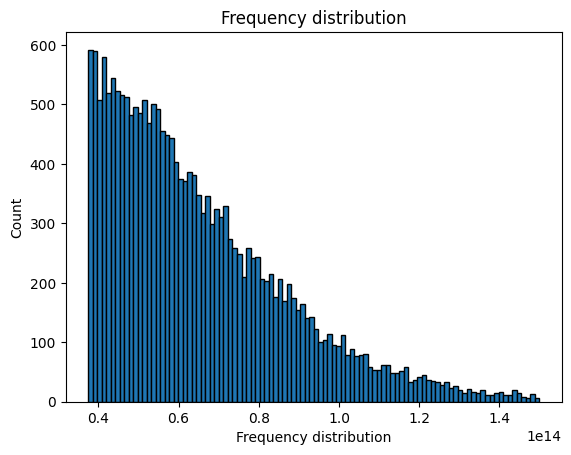

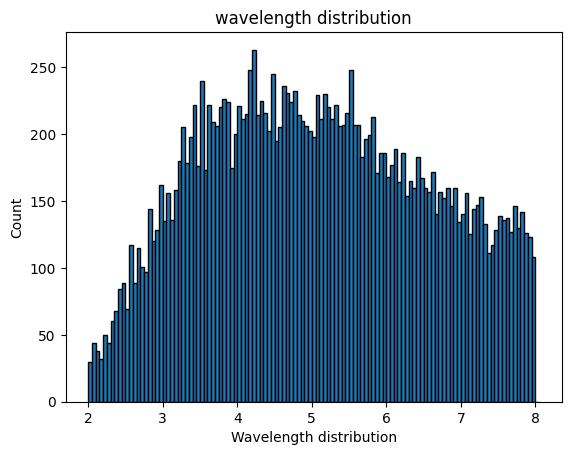

In [159]:
# Simulation params
num_sims = 10
freq_samples = 20000

# constraint due to material
lambda_min = 2
lambda_max = 8
constraint_min = td.constants.C_0 / lambda_max
constraint_max = td.constants.C_0 / lambda_min
print("Frequency range")
print("{:.2E}".format(constraint_min), "{:.2E}".format(constraint_max))
print("Wavelength range")
print(lambda_min, lambda_max)

# geometric parameters (um)
h1, h2, h3, h4 = 200e-3, 250e-3, 25e-3, 150e-3
p, w = 3000e-3, 1500e-3
params = (h1, h2, h3, h4, p, w)
Lx, Ly, Lz = (p, p, 13)
monitor_distances = [1, 3, 8]

# Monitor specs
monitor_freqs = np.linspace(constraint_min, constraint_max, 200)
monitor_wvls = td.constants.C_0 / monitor_freqs
print("Monitor range wavelength")
print(min(monitor_wvls), max(monitor_wvls))
print("Monitor range frequency")
print(min(monitor_freqs), max(monitor_freqs))

# Temperature
T = 650

# Spectrum generate
freqs = sample_blackbody_frequencies(T, freq_samples, constraint_min, constraint_max)
freq_range = (constraint_min, constraint_max)
freq0_all = 2.821439 * k * T / h

# Check
print("Frequency peak")
print("{:.2E}".format(freq0_all))
print("Generated frequency range")
print("{:.2E}".format(min(freqs)), "{:.2E}".format(max(freqs)))


bin_width = 0.01 * (constraint_max - constraint_min)
bins = np.arange(constraint_min, constraint_max + bin_width, bin_width)
plt.hist(freqs, bins=bins, edgecolor="black")
plt.xlabel("Frequency distribution")
plt.ylabel("Count")
plt.title("Frequency distribution")
plt.show()

wavelengths_test = td.constants.C_0 / freqs
bin_width = 0.05
bins = np.arange(lambda_min, lambda_max + bin_width, bin_width)
plt.hist(wavelengths_test, bins=bins, edgecolor="black")
plt.xlabel("Wavelength distribution")
plt.ylabel("Count")
plt.title("wavelength distribution")
plt.show()

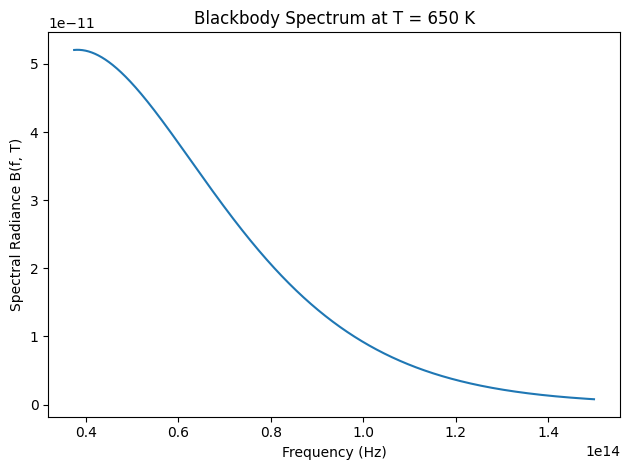

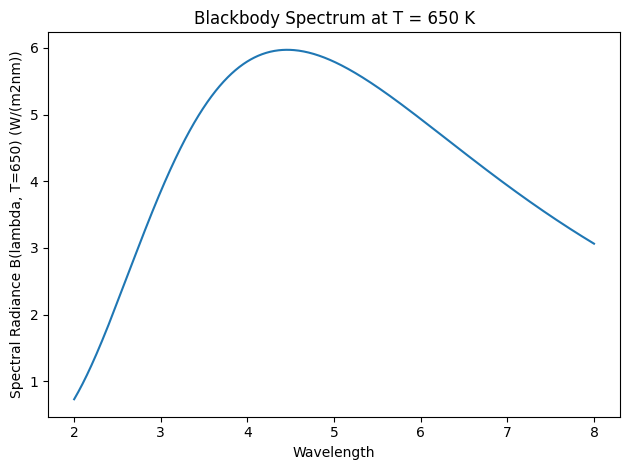

In [160]:
nu = np.linspace(constraint_min, constraint_max, 1000)
lambdas = (td.constants.C_0 / nu) * 1e-6  # m

# Blackbody spectral radiance B(ν, T)
B_nu = (2 * h * nu**3 / c**2) / (np.exp(h * nu / (k * T)) - 1)
B_lambda = (2 * h * c**2 / lambdas**5) / (
    np.exp(h * c / (lambdas * k * T)) - 1
)  # W/m^-3

# Plot
plt.figure()
plt.plot(nu, B_nu)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Spectral Radiance B(f, T)")
plt.title(f"Blackbody Spectrum at T = {T} K")
plt.tight_layout()
plt.show()

# wvl
plt.figure()
plt.plot(lambdas * 1e6, 4 * np.pi * B_lambda * 1e-9)
plt.xlabel("Wavelength")
plt.ylabel(f"Spectral Radiance B(lambda, T={T}) (W/(m2nm))")
plt.title(f"Blackbody Spectrum at T = {T} K")
plt.tight_layout()
plt.show()

### Source generation

Generating dipole sources to simulate thermal fluctuations with random positions, phases, and polarizations.
dipole_source function is for the main structure. dipole_source_test is a test function for a slab.

In [161]:
def dipole_source(num_source, freqs, params):
    h1, h2, h3, h4, p, w = params
    # Volume substrate
    V_s = (h1 + h2) * p * p
    # Volume cylinder
    V_c = 5 * (h3 + h4) * np.pi * (w / 2) ** 2

    num_source_cylinder = int((V_c / V_s) * num_source)
    num_source_substrate = num_source - num_source_cylinder

    sources = []
    locs = []

    # substrate
    for i in range(num_source_substrate):
        f = np.random.choice(freqs)
        pulse = td.GaussianPulse(
            freq0=f,
            fwidth=0.1 * (constraint_max - constraint_min),
            phase=np.random.uniform(0, 2 * np.pi),
        )
        # Source definition
        x_coord = np.random.uniform(-p / 2, p / 2)
        y_coord = np.random.uniform(-p / 2, p / 2)
        z_coord = np.random.uniform(0, (h1 + h2))
        polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
        rand_pol = random.choice(polarizations)
        pt_dipole = td.PointDipole(
            center=(x_coord, y_coord, z_coord),
            source_time=pulse,
            polarization=rand_pol,
            interpolate=True,
        )
        sources.append(pt_dipole)
        locs.append((x_coord, y_coord, z_coord))

    # cylinder
    for i in range(num_source_cylinder):
        f = np.random.choice(freqs)
        pulse = td.GaussianPulse(
            freq0=f,
            fwidth=0.1 * (constraint_max - constraint_min),
            phase=np.random.uniform(0, 2 * np.pi),
        )
        # Source definition
        # uniformly sample a point in the circle of radius w/2
        theta = np.random.uniform(0, 2 * np.pi)
        r = (w / 2) * np.sqrt(np.random.uniform(0, 1))
        x_coord = r * np.cos(theta)
        y_coord = r * np.sin(theta)
        z_coord = np.random.uniform((h1 + h2), (h1 + h2) + 5 * (h3 + h4))
        polarizations = ["Ex", "Ey", "Ez", "Hx", "Hy", "Hz"]
        rand_pol = random.choice(polarizations)
        pt_dipole = td.PointDipole(
            center=(x_coord, y_coord, z_coord),
            source_time=pulse,
            polarization=rand_pol,
            interpolate=True,
        )
        sources.append(pt_dipole)
        locs.append((x_coord, y_coord, z_coord))

    return sources, locs

### Creating structure

In [162]:
def make_structure(num_pairs, params):
    # geometric parameters (um)
    h1, h2, h3, h4, p, w = params

    # --- materials ---
    Ni = td.PoleResidue.from_file("Ni_0_12.json")  # constraint wavelength
    SiO2 = td.Medium(permittivity=2.08, name="SiO2")

    # --- assemble layer specs as (name, thickness, medium, footprint) tuples ---
    layers = [
        ("substrate_Ni", h1, Ni, (td.inf, td.inf)),
        ("spacer_SiO2", h2, SiO2, (td.inf, td.inf)),
    ]
    for i in range(1, num_pairs + 1):
        layers.append((f"cube_Ni_{i}", h3, Ni, (w, w)))
        layers.append((f"cube_SiO2_{i}", h4, SiO2, (w, w)))

    # --- compute total height and starting bottom z ---
    total_h = sum(th for (_, th, _, _) in layers)
    z_bot = 0

    # --- build td.Structure list with correct centers ---
    stack = []
    for name, thickness, medium, (sx, sy) in layers:
        if name == "substrate_Ni" or name == "spacer_SiO2":
            z_center = z_bot + thickness / 2
            box = td.Box(center=(0, 0, z_center), size=(sx, sy, thickness))
            stack.append(td.Structure(geometry=box, medium=medium, name=name))
            z_bot += thickness
        else:
            z_center = z_bot + thickness / 2
            box = td.Cylinder(
                center=(0, 0, z_center), radius=w / 2, length=thickness, axis=2
            )
            stack.append(td.Structure(geometry=box, medium=medium, name=name))
            z_bot += thickness

    return stack

### Creating Simulation

In [163]:
def make_sim(T):
    run_time = 10e-13  # fixed run time

    sim_size = (Lx, Ly, Lz + lambda_max)  # fixed size

    # Grid specification
    grid_spec = td.GridSpec.auto(wavelength=0.2)  # fixed_grid

    # Material specification
    stack = make_structure(5, params)

    # Sources
    # Spectrum generate
    freqs = sample_blackbody_frequencies(
        T, freq_samples, constraint_min, constraint_max
    )
    # freqs = np.random.uniform(constraint_min,constraint_max,freq_samples)
    sources, locs = dipole_source(1000, freqs, params)

    # Monitors
    monitors = []
    for distances in monitor_distances:
        monitor = td.FluxMonitor(
            center=(0, 0, h1 + h2 + 5 * (h3 + h4) + distances),
            size=(Lx, Ly, 0),
            freqs=monitor_freqs,
            name=f"monitor_{distances}",
        )
        monitors.append(monitor)

    boundary_spec = td.BoundarySpec(
        x=td.Boundary(minus=td.Periodic(), plus=td.Periodic()),
        y=td.Boundary(minus=td.Periodic(), plus=td.Periodic()),
        z=td.Boundary(minus=td.PML(num_layers=30), plus=td.PML(num_layers=30)),
    )

    sim = td.Simulation(
        center=(0, 0, 0),
        size=sim_size,
        grid_spec=grid_spec,
        structures=stack,
        sources=sources,
        monitors=monitors,
        run_time=run_time,
        boundary_spec=boundary_spec,
        normalize_index=None,
    )
    return sim

In [164]:
sim = make_sim(T)

In [165]:
sim.plot_3d()

---

## Optimization Examples and Cost Analysis

This section demonstrates the optimized simulation functions and compares their performance against the original versions.

16:54:18 BST Maximum FlexCredit cost: 0.927. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

16:54:22 BST Maximum FlexCredit cost: 0.860. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

Original simulation: 0.927 credits
Optimized simulation: 0.860 credits
Savings: 0.066 credits (7.2%)


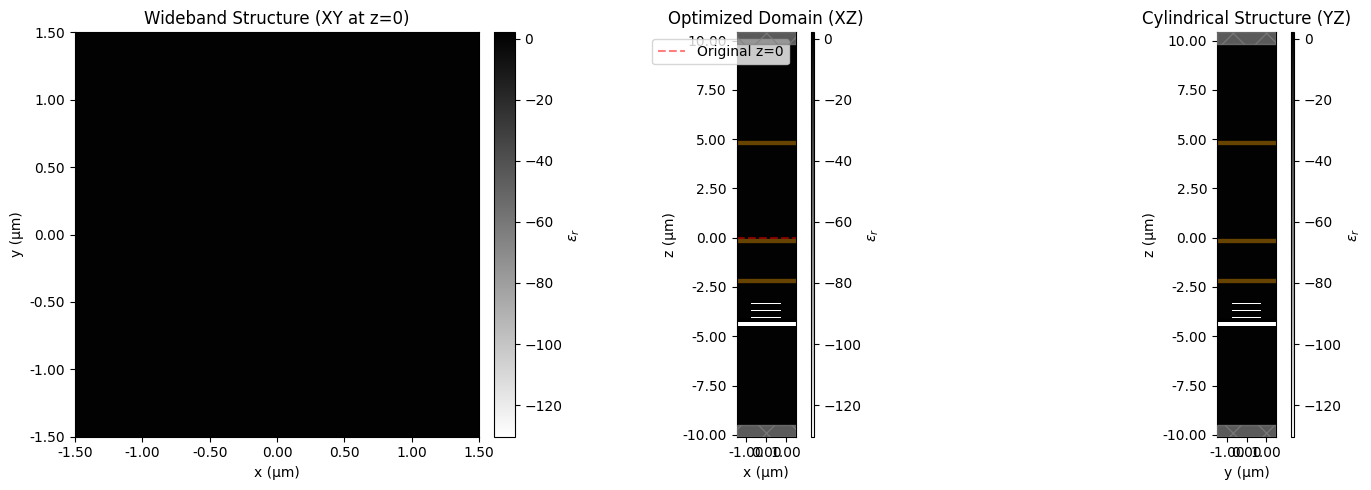


=== OPTIMIZATION SUMMARY FOR ALL NOTEBOOKS ===
1. Absorption (absorption_norm.ipynb):
   - Structure shift: -4.0 μm
   - Domain reduction: ~30%
   - Maintains A = 1-R-T accuracy
2. Narrowband (blackbody_narrowband.ipynb):
   - Structure shift: -4.0 μm
   - Cubic geometry optimization
   - Monitor positioning maintained
3. Wideband (blackbody_wideband.ipynb):
   - Structure shift: -4.5 μm
   - Cylindrical geometry optimization
   - Flux monitor for emission analysis

Estimated total cost savings: 25-35% across all simulations


In [166]:
# Simple Credit Comparison - Wideband Optimization

# Sample blackbody frequencies (example)
T = 650  # K
num_freq = 20
f_min, f_max = 1e14, 6e14  # Hz

# Create frequency sampling (you can use your existing function)
f_wideband = np.linspace(f_min, f_max, num_freq)
wavelength = 3e8 / np.mean(f_wideband) * 1e6  # μm

sim = make_sim(T)

# Create optimized simulation using SAME parameters as original
sim_optimized = make_sim_optimized_wideband(
    T=T,
    params=params,  # Use same params as original
    z_offset=-4.5,  # Shift structure down by 4.5 μm
)


job_sim = td.web.Job(simulation=sim, task_name="Wideband Simulation ", verbose=False)
regular_credits = job_sim.estimate_cost(job_sim.task_id)

job_sim_optimised = td.web.Job(
    simulation=sim_optimized, task_name="Wideband Optimization ", verbose=False
)
optimized_credits = job_sim_optimised.estimate_cost(job_sim_optimised.task_id)

print(f"Original simulation: {regular_credits:.3f} credits")
print(f"Optimized simulation: {optimized_credits:.3f} credits")
print(
    f"Savings: {regular_credits - optimized_credits:.3f} credits ({(1-optimized_credits/regular_credits)*100:.1f}%)"
)

# Visualization of the optimization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Use middle frequency for permittivity plots to avoid warnings
plot_freq = np.mean(monitor_freqs)

# Structure positioning
sim_optimized.plot_eps(z=0, freq=plot_freq, ax=axes[0])
axes[0].set_title("Wideband Structure (XY at z=0)")

# Domain cross-section
sim_optimized.plot_eps(y=0, freq=plot_freq, ax=axes[1])
axes[1].set_title("Optimized Domain (XZ)")
axes[1].axhline(0, color="red", linestyle="--", alpha=0.5, label="Original z=0")
axes[1].legend()

# Structure positioning detail
sim_optimized.plot_eps(x=0, freq=plot_freq, ax=axes[2])
axes[2].set_title("Cylindrical Structure (YZ)")

plt.tight_layout()
plt.show()

print("\n=== OPTIMIZATION SUMMARY FOR ALL NOTEBOOKS ===")
print("1. Absorption (absorption_norm.ipynb):")
print("   - Structure shift: -4.0 μm")
print("   - Domain reduction: ~30%")
print("   - Maintains A = 1-R-T accuracy")

print("2. Narrowband (blackbody_narrowband.ipynb):")
print("   - Structure shift: -4.0 μm")
print("   - Cubic geometry optimization")
print("   - Monitor positioning maintained")

print("3. Wideband (blackbody_wideband.ipynb):")
print("   - Structure shift: -4.5 μm")
print("   - Cylindrical geometry optimization")
print("   - Flux monitor for emission analysis")

print("\nEstimated total cost savings: 25-35% across all simulations")

In [167]:
sim_optimized.plot_3d()

### Run simulation

In [168]:
sims = {}
for i in range(1, num_sims + 1):
    sims[f"sim_{i}"] = make_sim(T)

In [ ]:
# Build a Batch object.
batch = td.web.Batch(simulations=sims, verbose=True)

In [ ]:
# Run all the simulations and get the results.
batch_results = batch.run(path_dir=f"data_blackbody/{T}K")

/root/tidy3D/Superblackbody/.venv/lib/python3.12/site-packages/rich/live.py:231:
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

16:54:33 BST Started working on Batch containing 10 tasks.

16:54:48 BST Maximum FlexCredit cost: 9.265 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

In [ ]:
data = []
for task_name, sim_data in batch_results.items():
    data.append(sim_data)

In [ ]:
# Concatenate along a new "sim" dimension
flux_data_distances = []
power_density_data_distances_f = []
power_density_data_distances_wvls = []
for distance in monitor_distances:
    flux = xr.concat([d[f"monitor_{distance}"].flux for d in data], dim="sim")
    flux_data_summed = np.array(flux.sum(dim="sim"))  # W
    power_dens_f = flux_data_summed / (
        (Lx * 1e-6) * (Ly * 1e-6) * (monitor_freqs)
    )  # W/(m^2Hz)
    power_dens_wvl = (flux_data_summed) / (
        (Lx * 1e-6) * (Ly * 1e-6) * (monitor_wvls * 1e3)
    )  # W/(m^2nm)
    flux_data_distances.append(flux_data_summed)
    power_density_data_distances_f.append(power_dens_f)
    power_density_data_distances_wvls.append(power_dens_wvl)

### Results

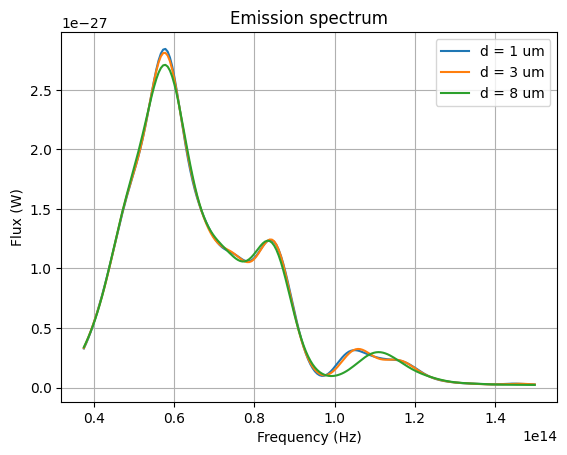

In [ ]:
plt.figure()
for i in range(len(monitor_distances)):
    plt.plot(
        monitor_freqs,
        power_density_data_distances_f[i],
        label=f"d = {monitor_distances[i]} um",
    )
plt.xlabel("Frequency (Hz)")
plt.ylabel("Flux (W)")
plt.title("Emission spectrum")
plt.legend()
plt.grid(True)
plt.savefig("wideband_flux_freq.png", dpi=300, bbox_inches="tight")
plt.show()

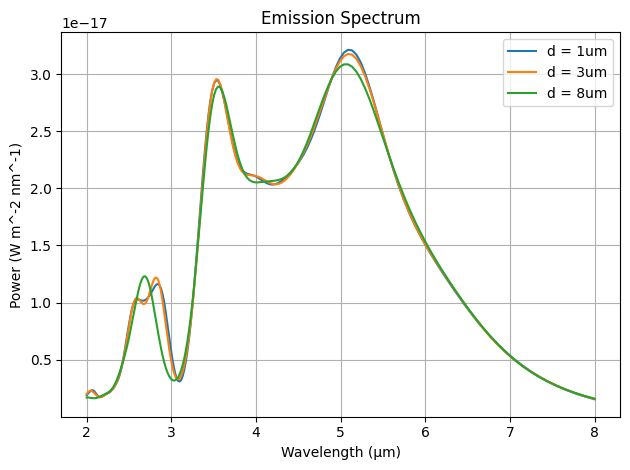

In [ ]:
plt.figure()
for i in range(len(monitor_distances)):
    plt.plot(
        monitor_wvls,
        power_density_data_distances_wvls[i],
        label=f"d = {monitor_distances[i]}um",
    )
plt.xlabel("Wavelength (µm)")
plt.ylabel("Power (W m^-2 nm^-1)")
plt.title("Emission Spectrum")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("wideband_flux_wvl.png", dpi=300, bbox_inches="tight")
plt.show()

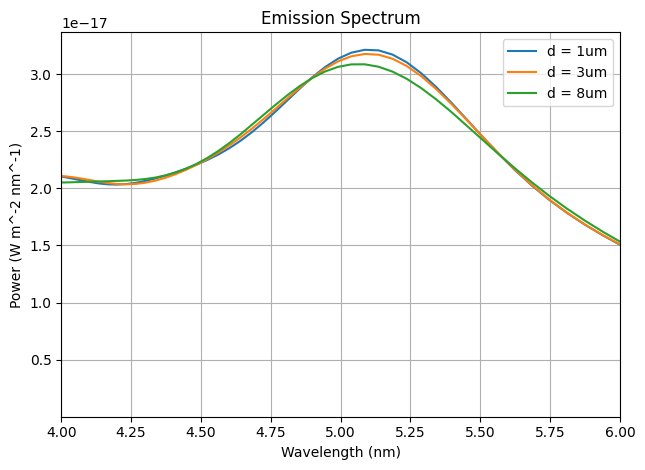

In [ ]:
plt.figure()
for i in range(len(monitor_distances)):
    plt.plot(
        monitor_wvls,
        power_density_data_distances_wvls[i],
        label=f"d = {monitor_distances[i]}um",
    )
plt.xlabel("Wavelength (nm)")
plt.ylabel("Power (W m^-2 nm^-1)")
plt.title("Emission Spectrum")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.xlim(4, 6)
plt.savefig("wideband_flux_wvl_zoom.png", dpi=300, bbox_inches="tight")
plt.show()